In [2]:
!pip install -U transformers datasets scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which 

In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/sarcasm_headlines.csv")

df.head()


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [4]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["is_sarcastic"], random_state=42)

# Convert Pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [5]:
from transformers import BertTokenizer

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(
        example["headline"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


# Apply the tokenizer to the dataset
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/44262 [00:00<?, ? examples/s]

Map:   0%|          | 0/11066 [00:00<?, ? examples/s]

In [6]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds)
    }

# training parameters
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none",
)

train_dataset = train_dataset.rename_column("is_sarcastic", "labels")
test_dataset = test_dataset.rename_column("is_sarcastic", "labels")

# Remove extra columns to avoid warning
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)


In [8]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.088200,0.172498,0.958070,0.953554,0.968483,0.939077
2,0.042100,0.097865,0.979487,0.977545,0.980941,0.974172
3,0.000100,0.099335,0.984457,0.983004,0.985341,0.980678


TrainOutput(global_step=16599, training_loss=0.12685043269505594, metrics={'train_runtime': 3497.4256, 'train_samples_per_second': 37.967, 'train_steps_per_second': 4.746, 'total_flos': 8734366149258240.0, 'train_loss': 0.12685043269505594, 'epoch': 3.0})

In [9]:
import torch

def predict_sarcasm(text):
    # Tokenize the input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    label = "Sarcastic 🤨" if predicted_class == 1 else "Not Sarcastic ✅"
    return label


In [18]:
trainer.predict(test_dataset)

PredictionOutput(predictions=array([[-2.9260683,  3.5735278],
       [ 3.5804167, -3.9581985],
       [ 3.388542 , -3.8902245],
       ...,
       [-2.0695844,  2.5995016],
       [-3.2229807,  3.878133 ],
       [ 3.5778296, -3.950728 ]], dtype=float32), label_ids=array([1, 0, 0, ..., 0, 1, 0]), metrics={'test_loss': 0.09786525368690491, 'test_accuracy': 0.9794867160672329, 'test_f1': 0.9775447620931843, 'test_precision': 0.9809410363311495, 'test_recall': 0.9741719242902208, 'test_runtime': 74.0285, 'test_samples_per_second': 149.483, 'test_steps_per_second': 18.695})

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5994
           1       0.98      0.97      0.98      5072

    accuracy                           0.98     11066
   macro avg       0.98      0.98      0.98     11066
weighted avg       0.98      0.98      0.98     11066



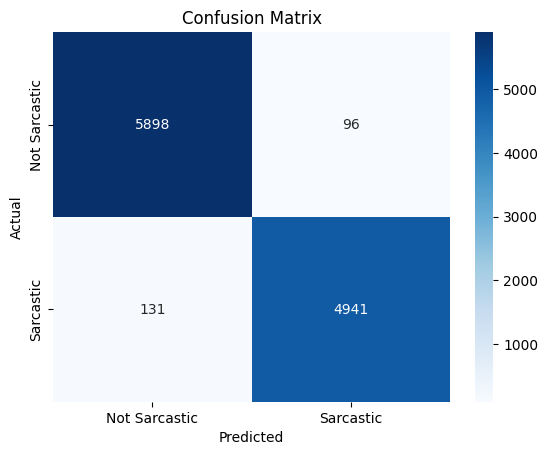

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred = trainer.predict(test_dataset)

preds = np.argmax(pred.predictions, axis=1)
labels = pred.label_ids

print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Sarcastic", "Sarcastic"], yticklabels=["Not Sarcastic", "Sarcastic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
model.save_pretrained("./sarcasm_model")
tokenizer.save_pretrained("./sarcasm_model")


('./sarcasm_model/tokenizer_config.json',
 './sarcasm_model/special_tokens_map.json',
 './sarcasm_model/vocab.txt',
 './sarcasm_model/added_tokens.json')